## What customer behaviors are associated with churn?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
df=pd.read_csv('data/processed/cleaned_data.csv')
df.head()

,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,start_hour_mean,haspurchase_mean,click_count_mean,view_count_mean,cart_count_mean,purchase_count_mean,time_to_click_mean,time_to_view_mean,time_to_cart_mean,time_to_purchase_mean,view_revenue_mean,cart_revenue_mean,purchase_revenue_mean,time_to_click_revenue_mean,time_to_view_revenue_mean,time_to_cart_revenue_mean,time_to_purchase_revenue_mean,session_number_mean,inter_session_time_mean,session_recency_mean,purchase_number_mean,inter_purchase_time_mean,purchase_recency_mean,length_sum,start_year_sum,start_yearday_sum,start_month_sum,start_monthday_sum,start_week_sum,start_weekday_sum,start_isweekend_sum,start_hour_sum,haspurchase_sum,click_count_sum,view_count_sum,cart_count_sum,purchase_count_sum,time_to_click_sum,time_to_view_sum,time_to_cart_sum,time_to_purchase_sum,view_revenue_sum,cart_revenue_sum,purchase_revenue_sum,time_to_click_revenue_sum,time_to_view_revenue_sum,time_to_cart_revenue_sum,time_to_purchase_revenue_sum,session_number_sum,inter_session_time_sum,session_recency_sum,purchase_number_sum,inter_purchase_time_sum,purchase_recency_sum,length_min,start_year_min,start_yearday_min,start_month_min,start_monthday_min,start_week_min,start_weekday_min,start_isweekend_min,start_hour_min,haspurchase_min,click_count_min,view_count_min,cart_count_min,purchase_count_min,time_to_click_min,time_to_view_min,time_to_cart_min,time_to_purchase_min,view_revenue_min,cart_revenue_min,purchase_revenue_min,time_to_click_revenue_min,time_to_view_revenue_min,time_to_cart_revenue_min,time_to_purchase_revenue_min,session_number_min,inter_session_time_min,session_recency_min,purchase_number_min,inter_purchase_time_min,purchase_recency_min,length_max,start_year_max,start_yearday_max,start_month_max,start_monthday_max,start_week_max,start_weekday_max,start_isweekend_max,start_hour_max,haspurchase_max,click_count_max,view_count_max,cart_count_max,purchase_count_max,time_to_click_max,time_to_view_max,time_to_cart_max,time_to_purchase_max,view_revenue_max,cart_revenue_max,purchase_revenue_max,time_to_click_revenue_max,time_to_view_revenue_max,time_to_cart_revenue_max,time_to_purchase_revenue_max,session_number_max,inter_session_time_max,session_recency_max,purchase_number_max,inter_purchase_time_max,purchase_recency_max,length_stddev,start_year_stddev,start_yearday_stddev,start_month_stddev,start_monthday_stddev,start_week_stddev,start_weekday_stddev,start_isweekend_stddev,start_hour_stddev,haspurchase_stddev,click_count_stddev,view_count_stddev,cart_count_stddev,purchase_count_stddev,time_to_click_stddev,time_to_view_stddev,time_to_cart_stddev,time_to_purchase_stddev,view_revenue_stddev,cart_revenue_stddev,purchase_revenue_stddev,time_to_click_revenue_stddev,time_to_view_revenue_stddev,time_to_cart_revenue_stddev,time_to_purchase_revenue_stddev,session_number_stddev,inter_session_time_stddev,session_recency_stddev,purchase_number_stddev,inter_purchase_time_stddev,purchase_recency_stddev,length_cv,start_year_cv,start_yearday_cv,start_month_cv,start_monthday_cv,start_week_cv,start_weekday_cv,start_isweekend_cv,start_hour_cv,haspurchase_cv,click_count_cv,view_count_cv,cart_count_cv,purchase_count_cv,time_to_click_cv,time_to_view_cv,time_to_cart_cv,time_to_purchase_cv,view_revenue_cv,cart_revenue_cv,purchase_revenue_cv,time_to_click_revenue_cv,time_to_view_revenue_cv,time_to_cart_revenue_cv,time_to_purchase_revenue_cv,session_number_cv,inter_session_time_cv,session_recency_cv,purchase_number_cv,inter_purchase_time_cv,purchase_recency_cv,session_count_ratio,click_count_ratio,transaction_count_ratio,session_count_month_lag0,session_count_month_lag1,session_count_month_lag2,session_count_month_lag3,session_count_month_ma3,purchase_count_month_lag0,purchase_count_month_lag1,purchase_count_month_lag2,purchase_count_month_lag3,purchase_count_month_ma3,purchase_revenue_month_lag0,purchase_revenue_month_lag1,purchas

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 112610
Columns : 271


In [4]:
df['target_event'].value_counts()

target_event
0    76480
1    36130
Name: count, dtype: int64

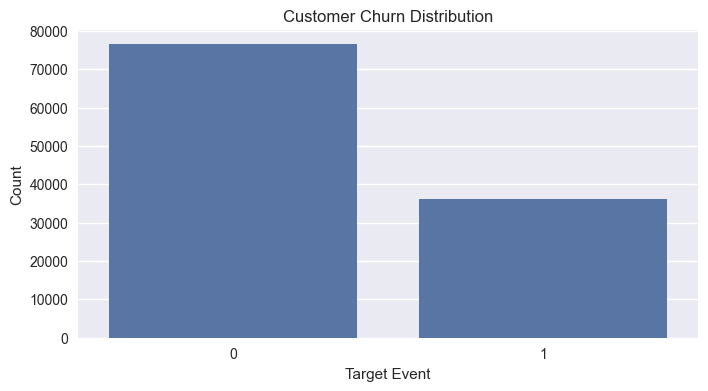

In [5]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x='target_event'
)
plt.title('Customer Churn Distribution')
plt.xlabel('Target Event')
plt.ylabel('Count')
plt.show()

# TOP CORRELATION ANALYSIS:

In [6]:
corr_target = (
    df.corr()['target_event']
      .sort_values(ascending=False)
)
corr_target.head(15)

target_event                1.000000
session_recency_min         0.534438
purchase_recency_min        0.516597
session_recency_mean        0.477474
purchase_recency_mean       0.474895
purchase_recency_max        0.367690
session_recency_max         0.352294
purchase_recency_sum        0.343076
purchase_number_cv          0.242120
purchase_number_stddev      0.208986
purchase_number_max         0.208615
haspurchase_sum             0.208615
purchase_number_mean        0.208614
purchase_latent_factor2     0.205096
purchase_latent_factor13    0.196236
Name: target_event, dtype: float64

In [7]:
corr_target.tail(15)

view_latent_factor16          -0.111913
start_weekday_min             -0.128462
purchase_count_month_ma3      -0.135262
start_hour_min                -0.141471
purchase_revenue_month_lag0   -0.147226
customer_value_month_lag0     -0.155762
session_count_month_lag0      -0.158345
purchase_count_month_lag1     -0.163119
purchase_recency_cv           -0.249613
purchase_count_month_lag0     -0.250551
session_recency_cv            -0.330524
time_step                     -0.347981
session_number_min                  NaN
purchase_number_min                 NaN
haspurchase_max                     NaN
Name: target_event, dtype: float64

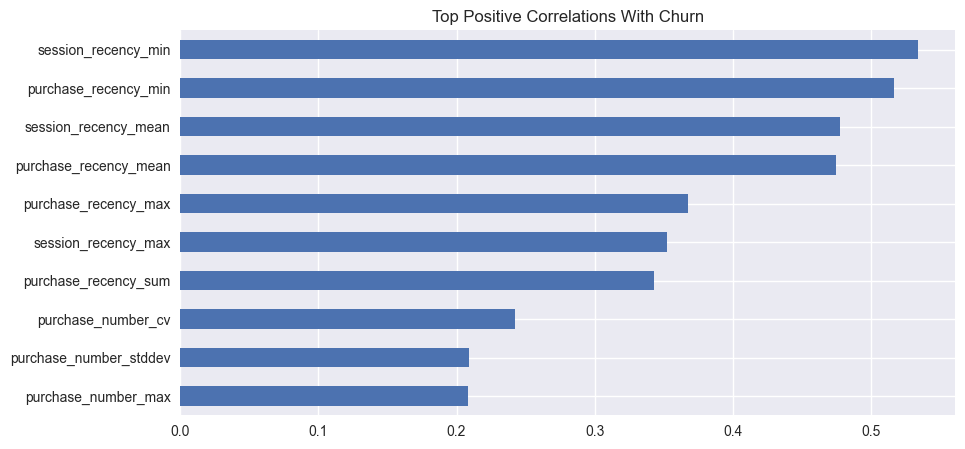

In [8]:
top_positive = corr_target[1:11]
plt.figure(figsize=(10,5))
top_positive.sort_values().plot(
    kind='barh'
)
plt.title('Top Positive Correlations With Churn')
plt.show()

## Insight:
### Higher recency values are strongly associated with churn.
### Customers who have not interacted recently are more likely to churn.

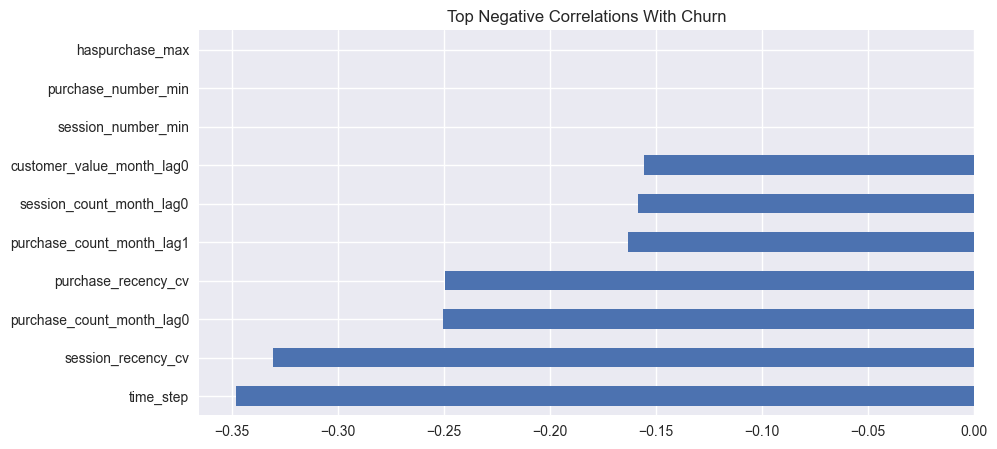

In [9]:
top_negative = corr_target.tail(10)
plt.figure(figsize=(10,5))
top_negative.sort_values().plot(
    kind='barh'
)
plt.title('Top Negative Correlations With Churn')
plt.show()

## Insight:
### Customers with higher purchase counts and customer value tend to remain active.

# BUSINESS FEATURES ANALYSIS:

In [10]:
business_features = [
    'session_recency_mean',
    'purchase_recency_mean',
    'purchase_count_month_lag0',
    'customer_value_month_lag0',
    'purchase_revenue_month_lag0'
]
business_features

['session_recency_mean',
 'purchase_recency_mean',
 'purchase_count_month_lag0',
 'customer_value_month_lag0',
 'purchase_revenue_month_lag0']

In [11]:
df[business_features].describe().T

,count,mean,std,min,25%,50%,75%,max
session_recency_mean,112610.0,48.783776,33.320691,0.004253,22.131146,42.688105,70.226878,177.28874
purchase_recency_mean,112610.0,47.690109,34.272625,0.001898,20.468226,40.730965,68.689670,177.84624
purchase_count_month_lag0,112610.0,1.548131,3.089025,0.000000,0.000000,0.000000,2.000000,189.00000
customer_value_month_lag0,112610.0,112.098359,276.123944,-71.066830,0.000000,34.159304,124.588738,12890.82900
purchase_revenue_month_lag0,112610.0,741.113775,2514.072892,0.000000,0.000000,0.000000,606.770000,152720.44000


# Session Recency:

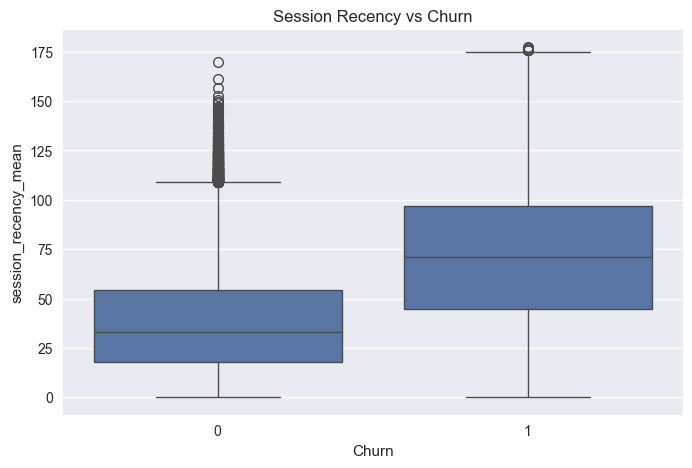

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='target_event',
    y='session_recency_mean'
)
plt.title('Session Recency vs Churn')
plt.xlabel('Churn')
plt.show()

## Insight:
### Churned customers show significantly higher session recency.

# Purchase Recency:

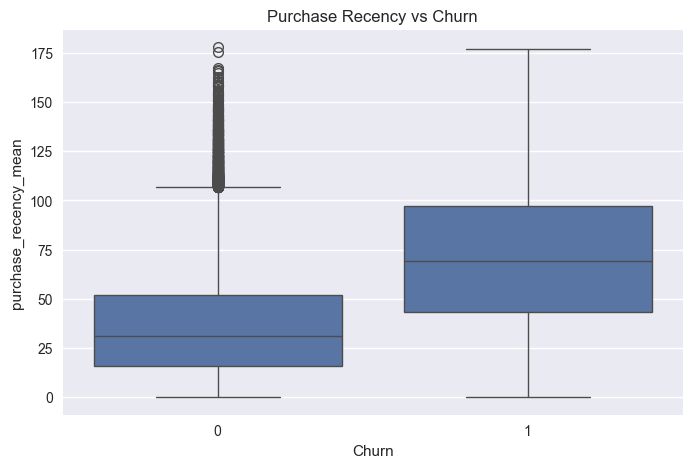

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='target_event',
    y='purchase_recency_mean'
)
plt.title('Purchase Recency vs Churn')
plt.xlabel('Churn')
plt.show()

## Insight:
### Customers who haven't purchased recently are more likely to churn.

# Purchse Count:

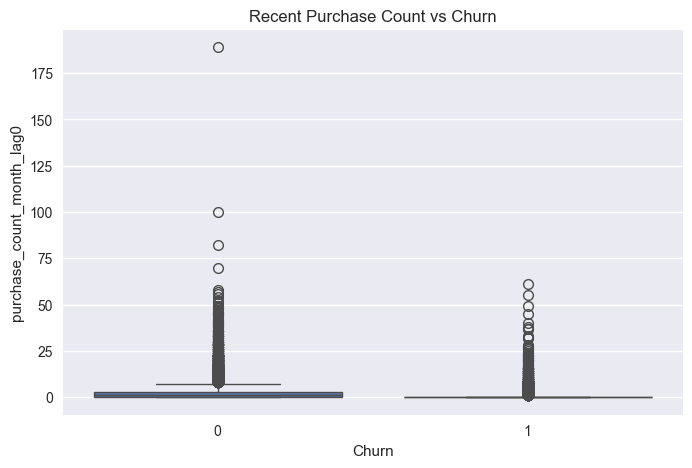

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='target_event',
    y='purchase_count_month_lag0'
)
plt.title('Recent Purchase Count vs Churn')
plt.xlabel('Churn')
plt.show()

## Insight:
### Active purchasers show lower churn rates.

# Customer Value:

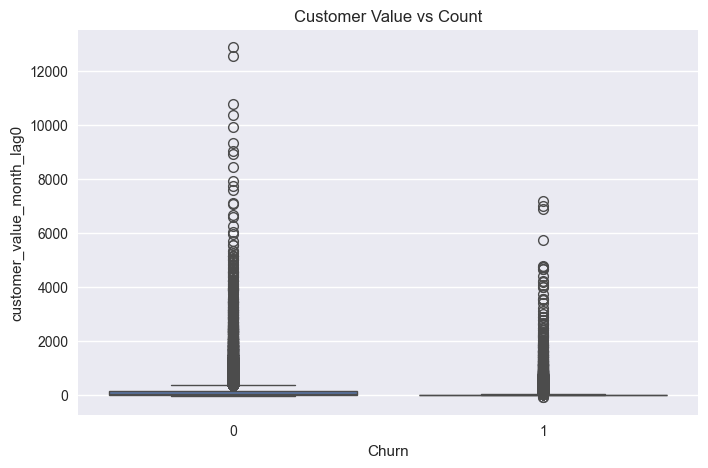

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='target_event',
    y='customer_value_month_lag0'
)
plt.title('Customer Value vs Count')
plt.xlabel('Churn')
plt.show()

## Insight:
### High-value customers tend to stay longer.

# Revenue Analysis:

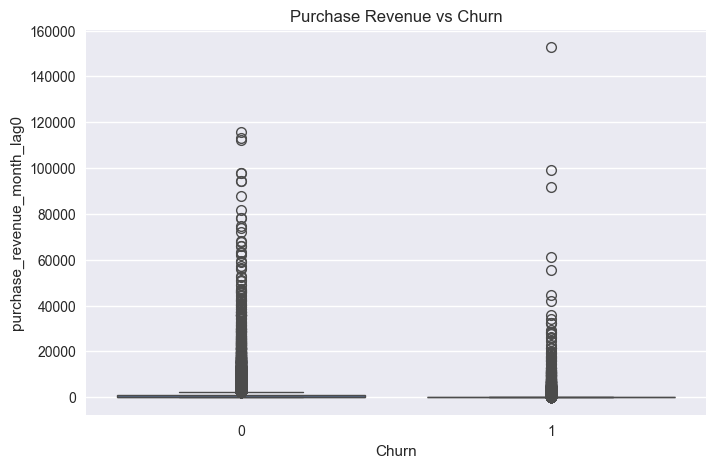

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='target_event',
    y='purchase_revenue_month_lag0'
)
plt.title('Purchase Revenue vs Churn')
plt.xlabel('Churn')
plt.show()

## Insight:
### Customers generating more revenue are less likely to churn.

# Correlation Heatmap

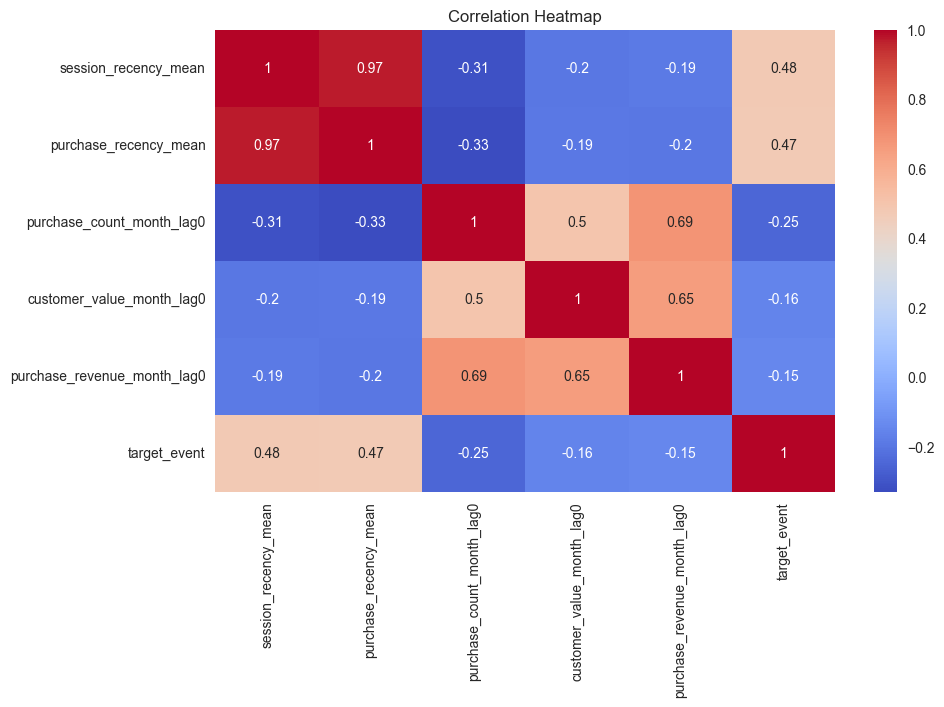

In [17]:
heatmap_features = [
    'session_recency_mean',
    'purchase_recency_mean',
    'purchase_count_month_lag0',
    'customer_value_month_lag0',
    'purchase_revenue_month_lag0',
    'target_event'
]

plt.figure(figsize=(10,6))
sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

## Key Insights:
### 1. Session recency is one of the strongest indicators of churn.
### 2. Purchase recency shows a strong positive relationship with churn.
### 3. Customers with fewer recent purchases are more likely to churn.
### 4. High customer value reduces churn probability.
### 5. Revenue-generating customers tend to remain active.
### 6. Customer inactivity is the primary driver of churn.

---

## Customers churn because:

### • They stop visiting.
### • They stop purchasing.
### • Their customer value declines.
### • Their revenue contribution decreases.